# 4A. Reporte escrito. Experimentos y análisis de algoritmos de búsqueda por comparación.


**Alumna:** Jovanna del Rocío Aguilar López

## Introducción

La búsqueda de elementos dentro de estructuras de datos es un problema central en el análisis de algoritmos, ya que su eficiencia depende tanto del método utilizado como de las características de los datos. En este trabajo se analizan distintos algoritmos de búsqueda con el objetivo de comparar su desempeño en términos de comparaciones y tiempo de ejecución.

A partir del planteamiento de Bentley y Yao (1976), la búsqueda puede entenderse como un proceso de reducción de incertidumbre, donde el objetivo es encontrar un valor con el menor número posible de comparaciones. Bajo este enfoque surgen algoritmos como B0, B1 y B2, que proponen distintas formas de recorrer y acotar el espacio de búsqueda.

En este contexto, se implementan y evalúan la búsqueda unaria, la búsqueda binaria acotada, la búsqueda doblada y la búsqueda doblemente doblada, con el fin de comparar su comportamiento con resultados experimentales y entender mejor sus ventajas en distintos escenarios.

## Desarrollo

### Búsqueda binaria acotada
La búsqueda binaria acotada es un algoritmo que localiza un elemento en un arreglo ordenado dividiendo el espacio de búsqueda en mitades. En cada repetición, se selecciona el elemento central del intervalo y, al compararlo, se descarta la mitad del arreglo que no puede contener el valor buscado. Este proceso se repite hasta encontrar la posición del elemento o determinar dónde debería ubicarse.

Su complejidad sigue un $O(\log_2 n)$, lo que implica que el número de comparaciones crece muy lentamente en relación con el tamaño del arreglo.

In [163]:
function menor_o_igual_conteo(x, a, contador)
    contador[] += 1
    return x <= a
end

menor_o_igual_conteo (generic function with 1 method)

In [165]:
function busqueda_binaria_acotada(A, x; lo=1, hi=length(A), contador=Ref(0))
    
    while lo <= hi
        #Obtenemos el punto medio
        mid = (lo + hi) ÷ 2  

        #Comparamos x con A[mid] y se cuenta la operación
        if menor_o_igual_conteo(x, A[mid], contador)  
            #buscamos a la izquierda
            hi = mid - 1               
        else
            #buscamos a la derecha
            lo = mid + 1               
        end
    end

    #Regresa la posición donde x debería estar
    return lo
end

busqueda_binaria_acotada (generic function with 1 method)

### Búsqueda unaría (B0)
Esta búsqueda es un algoritmo que localiza un elemento recorriendo el arreglo elemento por elemento desde el inicio. En cada iteración se compara el valor que se busca con el valor actual y se avanza hasta encontrarlo o llegar a una posición donde el valor ya no puede estar. Este método no aprovecha que el arreglo esté ordenado, por lo que revisa cada elemento del arreglo de principio a fin.

La complejidad de B0 sigue un $O(n)$, lo que implica que el número de comparaciones incrementa de manera proporcional al tamaño del arreglo. Esto significa que, en el peor caso, puede recorrer casi toda la lista hasta encontrar la posición del elemento.

In [168]:
function menor_que_conteo(a, x, contador)
    contador[] += 1
    return a < x
end

menor_que_conteo (generic function with 1 method)

In [170]:
function B0(A, x; contador=Ref(0))
    i = 1

    while i <= length(A) && menor_que_conteo(A[i], x, contador)
        i += 1
    end

    return i
end

B0 (generic function with 1 method)

### Búsqueda doblada (B1)
Esta búsqueda es un algoritmo que localiza un elemento en dos momentos. Primero, recorre el arreglo dando saltos cada vez más grandes con el propósito de encontrar un intervalo donde el valor que se busca pueda estar. Una vez que identifica este intervalo, aplica una búsqueda binaria dentro de ese rango. A diferencia de B0, este algoritmo no revisa todos los elementos uno a uno, sino que, mediante estos saltos, reduce rápidamente el espacio de búsqueda.

Su complejidad es de orden $O(\log n)$, lo que implica que el número de comparaciones crece muy lentamente respecto al tamaño del arreglo. Esto se debe a que el algoritmo es eficiente al localizar rápidamente una zona pequeña donde puede aplicar la búsqueda binaria. 

In [173]:
function B1(A, x; contador=Ref(0), sp=1)
    n = length(A)
    p = 0
    i = 1

    #Encontramos un intervalo donde pueda estar x
    while sp + i <= n && menor_que_conteo(A[sp + i], x, contador)
        p = i
        i += i
    end

    #Aplicamos búsqueda binaria en el intervalo encontrado
    return busqueda_binaria_acotada(A, x;
        lo = sp + p,
        hi = min(n, sp + i),
        contador = contador
    )
end

B1 (generic function with 1 method)

### Búsqueda  doblemente doblada (B2)
Está busqueda es un algoritmo que localiza un elemento en dos momentos. En el primero, busca un intervalo donde el valor puedar estar a través de saltos que crecen rápidamente. Después, una vez detectado el rango, aplica una búsqueda binaria dentro de ese segmento. A diferencia de B1, este método afina mejor la manera en la que se construye el intervalo para búsqueda, por lo que reduce comparaciones incesarias antes de aplicar la búsqueda binaria. 
\
Su complejidad es de orden $O(\log n)$,lo que significa que el número de compariones crece muy lento respecto al tamaño del arreglo. Se espera un desempeño ligeramente menor que B1. 

In [176]:
function B2(A, x; contador=Ref(0))
    n = length(A)

    #Si x va al inicio
    if menor_o_igual_conteo(x, A[1], contador)
        return 1
    end

    i = 1
    j = 2

    #Encontrando el rango
    while j <= n && menor_que_conteo(A[j], x, contador)
        i = j
        j *= 2
    end

    #Búsqueda binaria en el intervalo encontrado
    return busqueda_binaria_acotada(
        A, x;
        lo = i,
        hi = min(j, n),
        contador = contador
    )
end

B2 (generic function with 1 method)

### Cargamos las listas de posteos y las consultas  
Se utiliza un ciclo para leer todos los archivos contenidos en las carpetas, tanto de listas de posteos como de consultas.

In [179]:
using JSON

carpeta = "/Users/enriquear/Downloads/listas-posteo-con-perturbaciones"

archivos = [
    "listas-posteo-con-perturbaciones-p=016.json",
    "listas-posteo-con-perturbaciones-p=032.json",
    "listas-posteo-con-perturbaciones-p=064.json",
    "listas-posteo-con-perturbaciones-p=128.json",
    "listas-posteo-con-perturbaciones-p=256.json",
    "listas-posteo-con-perturbaciones-p=512.json"
]

listas_posteos = Dict()

for archivo in archivos
    ruta = joinpath(carpeta, archivo)
    listas_posteos[archivo] = JSON.parsefile(ruta)
end

In [180]:
using JSON

carpeta_consultas = "/Users/enriquear/Downloads/Consultas-20260413"

archivos_consultas = [
"consultas-1-listas-posteo.json",
"consultas-2-listas-posteo.json",
"consultas-3-listas-posteo.json",
"consultas-4-listas-posteo.json"
]

consultas_todas = Dict()

for archivo in archivos_consultas
    ruta = joinpath(carpeta_consultas, archivo)
    consultas_todas[archivo] = Int.(JSON.parsefile(ruta))
end

Se crea un diccionario que contiene los métodos de búsqueda junto con sus funciones correspondientes.

In [184]:
metodos = Dict(
    "Binaria acotada" => busqueda_binaria_acotada,
    "B0" => B0,
    "B1" => B1,
    "B2" => B2)

Dict{String, Function} with 4 entries:
  "B0"              => B0
  "Binaria acotada" => busqueda_binaria_acotada
  "B2"              => B2
  "B1"              => B1

### Comparaciones y tiempo, caso manual de lista p=512  

Se selecciona la lista de posteos correspondiente a `p=512` y se ordena para aplicar los métodos de búsqueda. Posteriormente, se recorren todas las consultas y, para cada método, se contabiliza el número de comparaciones realizadas.  

A partir de este total, se calcula un promedio de comparaciones por consulta, lo que permite tener una medida más representativa del desempeño de cada algoritmo. Finalmente, estos resultados se almacenan en una tabla para facilitar su comparación.

In [187]:
using DataFrames

archivo_posteo = "listas-posteo-con-perturbaciones-p=512.json"
A = Int.(listas_posteos[archivo_posteo]["reunion"])
sort!(A)

archivo_consulta = "consultas-1-listas-posteo.json"
Q = consultas_todas[archivo_consulta]

tabla_512 = DataFrame(
    metodo = String[],
    comparaciones_promedio = Float64[]
)

for (nombre, metodo) in metodos
    total = 0

    for x in Q
        ctr = Ref(0)
        metodo(A, x; contador=ctr)
        total += ctr[]
    end

    promedio = total / length(Q)

    push!(tabla_512, (nombre, promedio))
end

display(tabla_512)

Row,metodo,comparaciones_promedio
,String,Float64
1,B0,1.0
2,Binaria acotada,11.0
3,B2,1.0
4,B1,2.0


Se calcula el tiempo de ejecución de cada método utilizando todas las consultas. Para obtener resultados más estables, el proceso se repite varias veces y posteriormente se obtiene un tiempo promedio por consulta.  

In [190]:
using DataFrames

tiempos_512 = DataFrame(
    metodo = String[],
    tiempo_total = Float64[],
    tiempo_promedio = Float64[]
)

archivo_consulta = "consultas-1-listas-posteo.json"
Q = consultas_todas[archivo_consulta]

repeticiones = 1000

for (nombre, metodo) in metodos
    tiempo_total = @elapsed begin
        for _ in 1:repeticiones
            for x in Q
                metodo(A, x)
            end
        end
    end

    tiempo_promedio = tiempo_total / (length(Q) * repeticiones)

    push!(tiempos_512, (nombre, tiempo_total, tiempo_promedio))
end

display(tiempos_512)

Row,metodo,tiempo_total,tiempo_promedio
,String,Float64,Float64
1,B0,0.936673,9.36673e-8
2,Binaria acotada,0.776746,7.76746e-8
3,B2,0.686616,6.86616e-8
4,B1,0.699526,6.99526e-8


### Aplicación de los métodos de búsqueda
Para las demás consultas, usando ciclos, se aplica cada método de búsqueda a todas las listas y consultas. Con ello, se obtiene el promedio de comparaciones y tiempo, lo que permite comparar de forma más clara cada algoritmo.

Se crea una tabla utilizando DataFrames para almacenar los resultados obtenidos al ejecutar los distintos métodos de búsqueda. 

In [193]:
using DataFrames
resultados = DataFrame(
    metodo = String[],
    archivo_posteo = String[],
    archivo_consulta = String[],
    clave_posteo = String[],
    tamano_lista = Int[],
    num_consultas = Int[],
    comparaciones_totales = Int[],
    comparaciones_promedio = Float64[],
    tiempo_total_seg = Float64[],
    tiempo_promedio_seg = Float64[]
)


Row,metodo,archivo_posteo,archivo_consulta,clave_posteo,tamano_lista,num_consultas,comparaciones_totales,comparaciones_promedio,tiempo_total_seg,tiempo_promedio_seg
,String,String,String,String,Int64,Int64,Int64,Float64,Float64,Float64


Se define la función que evalúa el desempeño de cada método de búsqueda sobre una lista y un conjunto de consultas. Primero calcula el número total y promedio de comparaciones, y después mide el tiempo total y promedio de ejecución.  Finalmente, regresa estos en una sola estructura, lo que permite organizar los resultados y compararlos.

In [195]:
function evaluar_metodo(metodo, A, Q)
    comparaciones_totales = 0

    #Comparaciones
    for x in Q
        contador = Ref(0)
        metodo(A, x; contador=contador)
        comparaciones_totales += contador[]
    end

    comparaciones_promedio = comparaciones_totales / length(Q)

    #Tiempo
    repeticiones = 1000

    tiempo_total = @elapsed begin
        for _ in 1:repeticiones
            for x in Q
                metodo(A, x)
            end
        end
    end

    tiempo_promedio = tiempo_total / (length(Q) * repeticiones)

    return (
        comparaciones_totales = comparaciones_totales,
        comparaciones_promedio = comparaciones_promedio,
        tiempo_total = tiempo_total,
        tiempo_promedio = tiempo_promedio
    )
end

evaluar_metodo (generic function with 1 method)

In [196]:
using DataFrames

resultados = DataFrame(
    metodo = String[],
    archivo_posteo = String[],
    archivo_consulta = String[],
    clave_posteo = String[],
    tamano_lista = Int[],
    num_consultas = Int[],
    comparaciones_totales = Int[],
    comparaciones_promedio = Float64[],
    tiempo_total_seg = Float64[],
    tiempo_promedio_seg = Float64[]
)

Row,metodo,archivo_posteo,archivo_consulta,clave_posteo,tamano_lista,num_consultas,comparaciones_totales,comparaciones_promedio,tiempo_total_seg,tiempo_promedio_seg
,String,String,String,String,Int64,Int64,Int64,Float64,Float64,Float64


Se utiliza un conjunto de ciclos para aplicar cada método de búsqueda sobre todas las combinaciones de listas de posteos y archivos de consultas. Para cada archivo de posteo, se extrae la lista correspondiente y se ordena, ya que algunos métodos requieren que los datos estén en orden. Posteriormente, para cada archivo de consultas, se ejecuta el método de búsqueda seleccionado y se obtienen los resultados con la función de evaluación. Finalmente, los resultados se almacenan en la tabla resultados.

In [198]:
clave = "reunion"

for (nombre_metodo, funcion_metodo) in metodos
    for archivo_posteo in archivos
        datos_posteo = listas_posteos[archivo_posteo]
        A = Int.(datos_posteo[clave])
        sort!(A)

        for archivo_consulta in archivos_consultas
            Q = consultas_todas[archivo_consulta]

            r = evaluar_metodo(funcion_metodo, A, Q)

            push!(resultados, (
                nombre_metodo,
                archivo_posteo,
                archivo_consulta,
                clave,
                length(A),
                length(Q),
                r.comparaciones_totales,
                r.comparaciones_promedio,
                r.tiempo_total,
                r.tiempo_promedio
            ))
        end
    end
end


Se crean nuevas columnas a partir de los nombres de los archivos para simplificar su uso.

In [204]:
using Statistics

resultados.p = replace.(resultados.archivo_posteo,
    r"listas-posteo-con-perturbaciones-p=(\d+)\.json" => s"p=\1")

resultados.consulta = replace.(resultados.archivo_consulta,
    r"consultas-(\d+)-listas-posteo\.json" => s"consulta_\1")

96-element Vector{String}:
 "consulta_1"
 "consulta_2"
 "consulta_3"
 "consulta_4"
 "consulta_1"
 "consulta_2"
 "consulta_3"
 "consulta_4"
 "consulta_1"
 "consulta_2"
 "consulta_3"
 "consulta_4"
 "consulta_1"
 ⋮
 "consulta_1"
 "consulta_2"
 "consulta_3"
 "consulta_4"
 "consulta_1"
 "consulta_2"
 "consulta_3"
 "consulta_4"
 "consulta_1"
 "consulta_2"
 "consulta_3"
 "consulta_4"

### Tabla de comparaciones promedio  

Se reorganizan los resultados para construir una tabla donde cada fila corresponde a un método de búsqueda y a un valor de p, mientras que las columnas representan los distintos archivos de consulta.  

En cada celda se muestra el número de comparaciones promedio, lo que permite comparar de manera directa el desempeño de los métodos bajo diferentes escenarios.

In [206]:
tabla_comp = unstack(
    resultados,
    [:metodo, :p, :tamano_lista],
    :consulta,
    :comparaciones_promedio
)

println("\nTabla de comparaciones promedio:")
display(tabla_comp)


Tabla de comparaciones promedio:


Row,metodo,p,tamano_lista,consulta_1,consulta_2,consulta_3,consulta_4
,String,String,Int64,Float64?,Float64?,Float64?,Float64?
1,B0,p=016,3080,1.0,1.0,26.8825,1515.7
2,B0,p=032,3080,1.0,1.0,26.8825,1515.7
3,B0,p=064,3080,1.0,1.0,26.8825,1515.7
4,B0,p=128,3080,1.0,1.0,26.8825,1515.7
5,B0,p=256,3080,1.0,1.0,26.8825,1515.7
6,B0,p=512,3080,1.0,1.0,26.8825,1515.7
7,Binaria acotada,p=016,3080,11.0,11.0,11.6622,11.6615
8,Binaria acotada,p=032,3080,11.0,11.0,11.6622,11.6615
9,Binaria acotada,p=064,3080,11.0,11.0,11.6622,11.6615


#### Resultados comparaciones 

En la tabla se observa que los valores de comparaciones promedio se mantienen constantes para cada método a lo largo de las distintas listas. En el caso de B0, se presentan valores bajos en algunas consultas y valores considerablemente más altos en otras. Por su parte, la búsqueda binaria acotada muestra un número de comparaciones estable en todas las consultas. En cuanto a B1 y B2, ambos métodos presentan valores menores en comparación con la búsqueda binaria acotada, manteniéndose también constantes entre los distintos escenarios.  

### Tabla de tiempos promedio
La tabla presenta los tiempos promedio de ejecución para cada método, organizados por valor de p y tipo de consulta. Esto permite comparar de forma directa el desempeño de los métodos bajo distintos escenarios, identificando variaciones en eficiencia según el tamaño de la lista y el conjunto de consultas evaluado.

In [209]:
tabla_tiempo = unstack(
    resultados,
    [:metodo, :p],
    :archivo_consulta,
    :tiempo_promedio_seg
)

println("\nTabla de tiempos promedio:")
display(tabla_tiempo)


Tabla de tiempos promedio:


Row,metodo,p,consultas-1-listas-posteo.json,consultas-2-listas-posteo.json,consultas-3-listas-posteo.json,consultas-4-listas-posteo.json
,String,String,Float64?,Float64?,Float64?,Float64?
1,B0,p=016,3.22642e-10,3.27775e-10,1.70119e-8,6.74854e-7
2,B0,p=032,3.25354e-10,3.21654e-10,1.7229e-8,6.7239e-7
3,B0,p=064,3.23325e-10,3.19133e-10,1.70648e-8,6.6644e-7
4,B0,p=128,3.204e-10,3.23558e-10,1.70655e-8,6.70354e-7
5,B0,p=256,3.15162e-10,3.14158e-10,1.67325e-8,6.61629e-7
6,B0,p=512,3.22604e-10,3.20408e-10,1.70523e-8,6.67051e-7
7,Binaria acotada,p=016,1.96256e-8,1.94239e-8,2.91346e-8,2.89701e-8
8,Binaria acotada,p=032,1.97173e-8,1.94764e-8,2.90762e-8,3.89665e-8
9,Binaria acotada,p=064,2.06847e-8,2.0398e-8,2.94668e-8,2.93695e-8


#### Resultados de tiempo  

En la tabla de tiempos se observa que los valores promedio se mantienen muy bajos para todos los métodos. Asimismo, se identifican ligeras variaciones entre ellos dependiendo de la consulta evaluada.  

En particular, la búsqueda secuencial (B0), la búsqueda binaria acotada y sus variantes (B1 y B2) presentan tiempos del mismo orden de magnitud, sin diferencias marcadas entre métodos.  

Finalmente, los tiempos se mantienen prácticamente constantes.

### Gráficos por conjunto de consultas

#### Gráfica de comparaciones por consulta

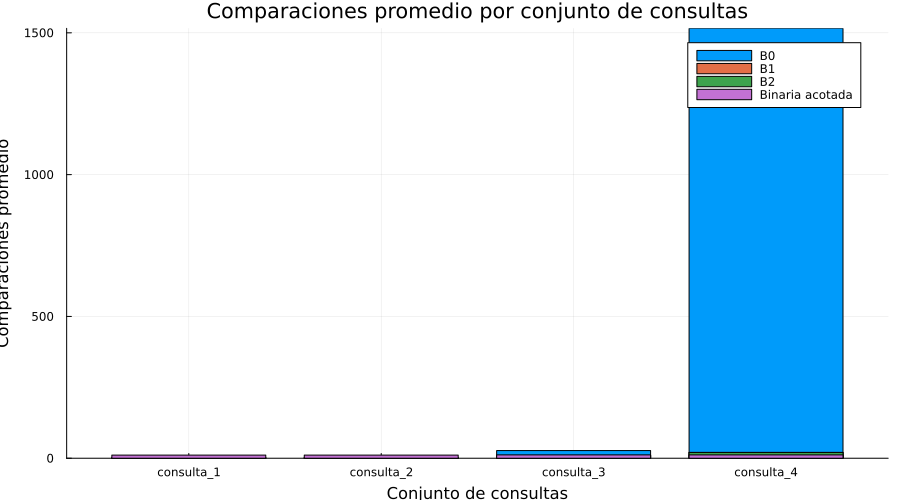

In [213]:
using Plots
using DataFrames
using Statistics
#Promedio por método y consulta
resumen_consulta = combine(
    groupby(resultados, [:consulta, :metodo]),
    :comparaciones_promedio => mean => :comparaciones)

#Orden
orden_metodos = ["B0", "Binaria acotada", "B1", "B2"]
orden_consultas = ["consulta_1", "consulta_2", "consulta_3", "consulta_4"]

resumen_consulta.metodo = string.(resumen_consulta.metodo)
resumen_consulta.consulta = string.(resumen_consulta.consulta)

resumen_consulta = sort(
    resumen_consulta,
    [:consulta, :metodo],
    by = (x -> x in orden_consultas ? findfirst(==(x), orden_consultas) :
          x in orden_metodos ? findfirst(==(x), orden_metodos) : 999))

#Gráfica por consulta
bar(resumen_consulta.consulta,
    resumen_consulta.comparaciones,
    group = resumen_consulta.metodo,
    xlabel = "Conjunto de consultas",
    ylabel = "Comparaciones promedio",
    title = "Comparaciones promedio por conjunto de consultas",
    legend = :topright,
    size = (900, 500))

Esta gráfica permite observar el comportamiento de los algoritmos según el conjunto de consultas evaluado. En particular, se aprecia que B0 incrementa considerablemente el número de comparaciones en las consultas 3 y 4, especialmente en esta última, donde supera al resto de los métodos.

#### Gráfica de tiempo por consulta

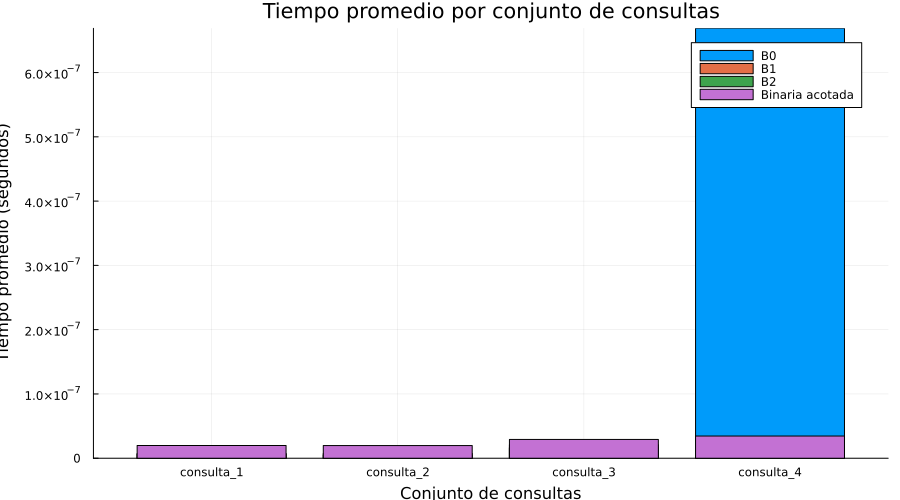

In [216]:
using Plots
using DataFrames
using Statistics

resumen_tiempo_consulta = combine(
    groupby(resultados, [:consulta, :metodo]),
    :tiempo_promedio_seg => mean => :tiempo)

resumen_tiempo_consulta.metodo = string.(resumen_tiempo_consulta.metodo)
resumen_tiempo_consulta.consulta = string.(resumen_tiempo_consulta.consulta)

bar(resumen_tiempo_consulta.consulta,
    resumen_tiempo_consulta.tiempo,
    group = resumen_tiempo_consulta.metodo,
    xlabel = "Conjunto de consultas",
    ylabel = "Tiempo promedio (segundos)",
    title = "Tiempo promedio por conjunto de consultas",
    legend = :topright,
    size = (900, 500))

La gráfica de tiempos muestra un comportamiento similar al observado en las comparaciones promedio. En particular, B0 presenta un incremento considerable en la consulta 4, donde el tiempo de ejecución supera al resto de los métodos. Esto es consistente con el aumento en el número de comparaciones que realiza este algoritmo cuando debe recorrer una mayor parte de la lista.

### Tabla resumen

In [219]:
resumen_global = combine(
    groupby(resultados, [:metodo, :p]),
    :comparaciones_promedio => mean,
    :tiempo_promedio_seg => mean
)

println("\nResumen general:")
display(resumen_global)


Resumen general:


Row,metodo,p,comparaciones_promedio_mean,tiempo_promedio_seg_mean
,String,String,Float64,Float64
1,B0,p=016,386.146,1.73129e-7
2,B0,p=032,386.146,1.72567e-7
3,B0,p=064,386.146,1.71037e-7
4,B0,p=128,386.146,1.72016e-7
5,B0,p=256,386.146,1.69748e-7
6,B0,p=512,386.146,1.71187e-7
7,Binaria acotada,p=016,11.3309,2.42886e-8
8,Binaria acotada,p=032,11.3309,2.68091e-8
9,Binaria acotada,p=064,11.3309,2.49797e-8


#### Resultados generales

En el resumen general se observa que el número de comparaciones promedio se mantiene constante para cada método a lo largo de los distintos valores de p (listas de posteo). En particular, B0 presenta los valores más altos, mientras que la búsqueda binaria acotada, B1 y B2 muestran valores considerablemente menores.  

En cuanto al tiempo promedio, todos los métodos presentan valores muy bajos y del mismo orden de magnitud, con ligeras variaciones entre ellos. Asimismo, no se identifican cambios relevantes en los tiempos.  

### Gráficos

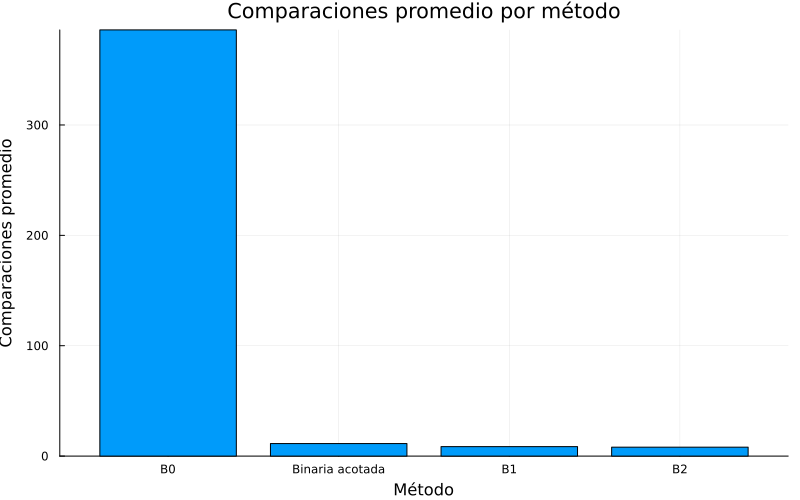

In [222]:
using Statistics
using Plots
#Coventimos a texto
resumen_global.metodo = string.(resumen_global.metodo)
resumen_global.p = string.(resumen_global.p)

#Agrupamos por método
resumen_metodo = combine(
    groupby(resumen_global, :metodo),
    :comparaciones_promedio_mean => mean => :comparaciones
)

#Orden
orden = ["B0", "Binaria acotada", "B1", "B2"]
resumen_metodo = sort(resumen_metodo, :metodo, by = x -> findfirst(==(x), orden))

#Gráfica
grafica_comp = bar(
    resumen_metodo.metodo,
    resumen_metodo.comparaciones,
    xlabel = "Método",
    ylabel = "Comparaciones promedio",
    title = "Comparaciones promedio por método",
    legend = false,
    size = (800, 500)
)

display(grafica_comp)

De forma general, la gráfica muestra una diferencia clara entre los métodos. B0 presenta un número de comparaciones mayor, mientras que la búsqueda binaria acotada, B1 y B2 mantienen valores mucho más bajos y bastante similares entre sí.

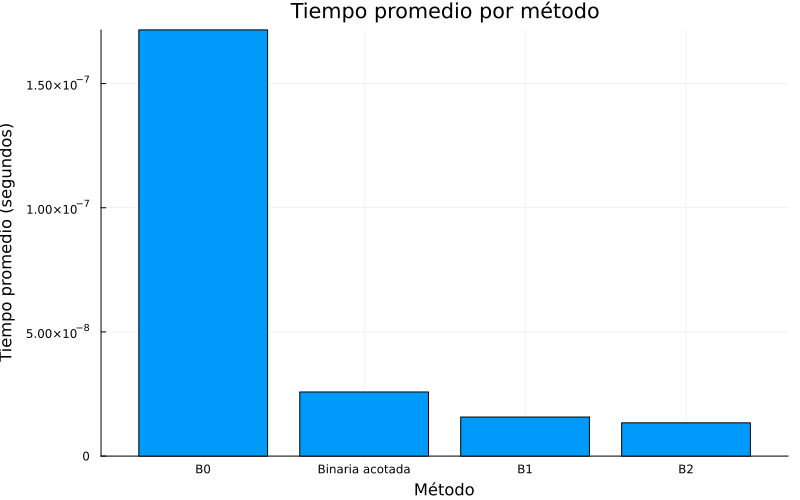

In [224]:
using Statistics
using Plots

#Agrupar por método
resumen_metodo = combine(
    groupby(resumen_global, :metodo),
    :tiempo_promedio_seg_mean => mean => :tiempo
)

#Convertir a texto
resumen_metodo.metodo = string.(resumen_metodo.metodo)

#Orden
orden = ["B0", "Binaria acotada", "B1", "B2"]
resumen_metodo = sort(resumen_metodo, :metodo, by = x -> findfirst(==(x), orden))

#Gráfica
bar(
    resumen_metodo.metodo,
    resumen_metodo.tiempo,
    xlabel = "Método",
    ylabel = "Tiempo promedio (segundos)",
    title = "Tiempo promedio por método",
    legend = false,
    size = (800, 500)
)

De forma general, la gráfica muestra que B0 presenta los tiempos promedio más altos, mientras que los métodos de búsqueda binaria, B1 y B2 mantienen tiempos menores y bastante cercanos entre sí.

## Discusión
A partir de los resultados, se observa un comportamiento consistente entre el número de comparaciones y los tiempos de ejecución. El método B0 presenta valores considerablemente mayores, especialmente en la consulta 4, donde el número de comparaciones y el tiempo promedio aumentan de forma clara. Esto es esperado, ya que B0 realiza una búsqueda lineal y debe recorrer los elementos uno por uno hasta encontrar la posición del valor buscado.

En contraste, los métodos de búsqueda binaria acotada, B1 y B2 reducen significativamente el número de comparaciones y mantienen un comportamiento más estable entre los distintos conjuntos de consultas. Esto coincide con su complejidad teórica, ya que estos métodos reducen el espacio de búsqueda de forma logarítmica, en lugar de recorrer la lista desde el inicio.

El análisis por conjunto de consultas permite observar diferencias que en el resumen general pueden quedar ocultas. Mientras B0 depende más de la posición de los valores consultados, los métodos basados en búsqueda binaria muestran menor variación entre escenarios. 

En conjunto, los resultados coinciden con lo esperado, los métodos que reducen mejor el espacio de búsqueda requieren menos comparaciones y menores tiempos de ejecución.

## Conclusión  

En este trabajo se evaluaron distintos métodos de búsqueda sobre listas ordenadas, observando diferencias claras en su desempeño. Los resultados muestran que los algoritmos que aprovechan la estructura ordenada de los datos, como la búsqueda binaria acotada, B1 y B2, logran reducir significativamente el número de comparaciones y los tiempos de ejecución en comparación con la búsqueda B0.

Asimismo, se confirma que las diferencias entre los métodos más eficientes son pequeñas, lo que indica que todos mantienen un comportamiento adecuado para este tipo de problemas. En conjunto, los resultados empíricos coinciden con lo esperado desde el punto de vista teórico.

## Biblografía

- Bentley, J. L., & Yao, A. C. (1976). An almost optimal algorithm for unbounded searching. Information Processing Letters, 5(3), 82–87